# Client demo

Demonstrate the use of the Client (Assetto Corsa Sim interface) without the OpenAI Gym interface layer.

In [8]:
%matplotlib inline

import matplotlib.pyplot as plt
import sys
import os
import numpy as np
import pandas as pd
import glob as glob
import time
import pickle
from omegaconf import OmegaConf

# add custom paths
sys.path.extend([os.path.abspath('./assetto_corsa_gym')])
import AssettoCorsaEnv.assettoCorsa as assettoCorsa

# Configure the logging system
import logging
logger = logging.getLogger(__name__)
logging.basicConfig(
    level=logging.INFO,  # Set the logging level (DEBUG, INFO, WARNING, ERROR, CRITICAL)
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',  # Format of the log messages
    datefmt='%Y-%m-%d %H:%M:%S',  # Format of the timestamp
)


# load config file

In [9]:
config = OmegaConf.load("config.yml")
client = assettoCorsa.make_client_only(config.AssettoCorsa)

# Show static info

In [10]:
static_info = client.simulation_management.get_static_info()
ac_mod_config = client.simulation_management.get_config()

logger.info("Static info:")
for i in static_info:
    logger.info(f"{i}: {static_info[i]}")
logger.info("AC Mod config:")
for i in ac_mod_config:
    logger.info(f"{i}: {ac_mod_config[i]}")


INFO:__main__:Static info:
INFO:__main__:CarName: ks_lamborghini_sesto_elemento
INFO:__main__:CAR_WHEEL_R: [0.32350000739097595, 0.32350000739097595, 0.3305000066757202, 0.3305000066757202]
INFO:__main__:WindDirection: 0
INFO:__main__:TyreContactPoint_RR: [-449.2483215332031, -7.094364166259766, 321.7445068359375]
INFO:__main__:WindSpeed: 10
INFO:__main__:TyreContactPoint_FL: [-448.9138488769531, -7.076909065246582, 318.73626708984375]
INFO:__main__:WorldPosition: [-449.17584228515625, -6.623411655426025, 320.3795166015625]
INFO:__main__:penaltiesEnabled: 1
INFO:__main__:isCarInPit: 0
INFO:__main__:TyreContactPoint_FR: [-447.6374816894531, -7.087100982666016, 319.7535095214844]
INFO:__main__:TyreContactPoint_RL: [-450.49468994140625, -7.084310531616211, 320.7516784667969]
INFO:__main__:CAR_WHEELBASE: 2.56144417684981
INFO:__main__:LastSplits: [0, 0, 0]
INFO:__main__:TrackConfiguration: gp
INFO:__main__:isCarInPitlane: 0
INFO:__main__:CAR_TRACK: 1.5935003781319823
INFO:__main__:autoShif

# Test gear shift

In [11]:
# test gear shifting
client.controls.set_controls(0,-1,1, enable_gear_shift=True, shift_up=True)
client.controls.apply_local_controls()
time.sleep(0.01)
client.controls.set_controls(0,-1,1, enable_gear_shift=True, shift_up=False)
client.controls.apply_local_controls()

time.sleep(1.0)
client.controls.set_controls(0,-1,1, enable_gear_shift=True, shift_down=True)
client.controls.apply_local_controls()
time.sleep(0.01)
client.controls.set_controls(0,-1,1, enable_gear_shift=True, shift_down=False)
client.controls.apply_local_controls()

# Apply actions and recover the car

In [12]:
states = []

client.reset()

# shift up
client.controls.set_controls(0,-1,1, enable_gear_shift=True, shift_up=True)
client.controls.apply_local_controls()
time.sleep(0.01)
client.controls.set_controls(0,-1,1, enable_gear_shift=True, shift_up=False)
client.controls.apply_local_controls()

for i in range(100):
    if i % 2 == 0:
        steer = .1
    else:
        steer = -.1
    client.controls.set_controls(steer=steer, acc=0.5, brake=-1.)
    client.respond_to_server()
    state = client.step_sim()
    states.append(state.copy())
    time.sleep(0.01)

client.controls.set_defaults()
client.respond_to_server()
client.simulation_management.send_reset()
client.close()

INFO:AssettoCorsaEnv.ac_client:sending reset to simulation management server
INFO:AssettoCorsaEnv.ac_client:AC Client. Listening at host: localhost port: 2345
INFO:AssettoCorsaEnv.ac_client:Client connected on 2345
INFO:AssettoCorsaEnv.ac_client:sending reset to simulation management server


# Plot states

In [13]:
df = pd.DataFrame(states)
df.columns

Index(['done', 'steerAngle', 'speed', 'pitch', 'fl_tire_temperature_core',
       'SlipAngle_rr', 'angular_velocity_y', 'angular_velocity_x',
       'angular_velocity_z', 'SlipAngle_fr', 'wheel_speed_fl',
       'world_position_y', 'world_position_x', 'world_position_z', 'yaw',
       'tyreContactHeading_FL_y', 'total_errors_out_of_sync',
       'tyreContactHeading_FL_z', 'BestLap', 'SlipAngle_fl',
       'tyreContactHeading_FL_x', 'Dy_fl', 'wheel_speed_rl', 'Mz',
       'fl_wheel_load', 'cgHeight', 'rr_damper_linear_potentiometer',
       'wheel_speed_rr', 'isInPit', 'Dy_fr', 'fr_tire_temperature_core',
       'rr_tire_pressure', 'CamberRad', 'local_velocity_z', 'local_velocity_x',
       'local_velocity_y', 'tyreContactHeading_FR_z',
       'tyreContactHeading_FR_y', 'tyreContactHeading_FR_x', 'brakeStatus',
       'accStatus', 'actualGear', 'currentTime', 'fr_wheel_load',
       'timestamp_ac', 'tyre_slip_ratio_fl', 'tyre_loaded_radius',
       'velocity_x', 'velocity_y', 'velocity_

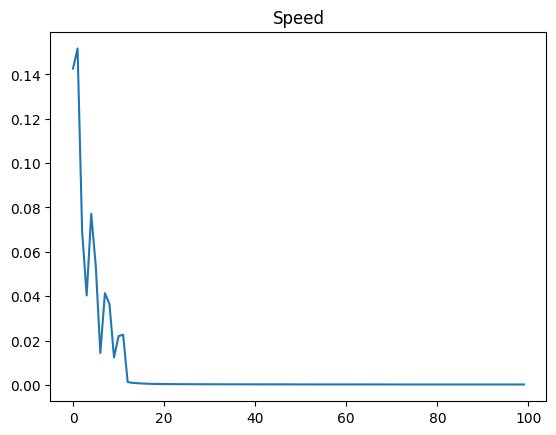

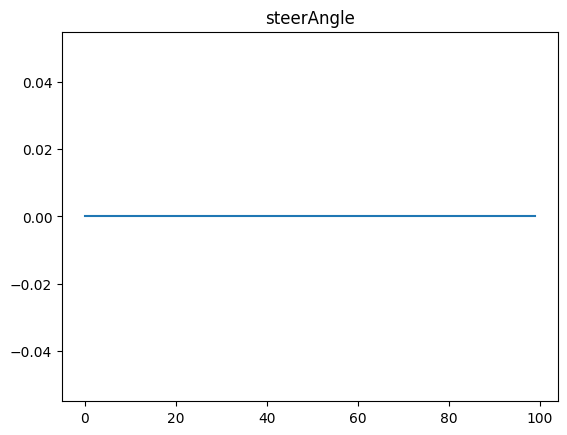

In [14]:
plt.title("Speed")
plt.plot(df.speed)
plt.show()

plt.title("steerAngle")
plt.plot(df.steerAngle)
plt.show()